<h1 align='center', style= color:blue> Unsupervised Learning</h1>  

Training on data with **no labels** (only X, no target y). The model finds hidden patterns/structure on its own.

**Two main types:**
1. **Clustering** — group similar data points together
   - e.g. K-Means, DBSCAN, Hierarchical Clustering
2. **Dimensionality Reduction** — reduce number of features while retaining information
   - e.g. PCA, LDA

**vs Supervised Learning:** supervised uses labeled data (X, y) to predict outcomes; unsupervised only has X and explores structure/patterns.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
iris = pd.read_csv('iris.data',header=None)
iris.head()

,0,1,2,3,4
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [20]:
iris.columns = ['sepal_length', 'sepal_width','petal_length','petal_width','Flower']
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,Flower
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


### Column creation

In [21]:
ip = iris.drop('Flower', axis=1)
ip.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [22]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=3)
km.fit(ip)

C:\Users\KIIT\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [23]:
km_pred = km.predict(ip)
km_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2,
       2, 2, 2, 1, 1, 2, 2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 1, 1, 2, 2, 2, 2,
       2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 1], dtype=int32)

In [24]:
centroid = km.cluster_centers_
centroid

array([[5.006     , 3.418     , 1.464     , 0.244     ],
       [5.9016129 , 2.7483871 , 4.39354839, 1.43387097],
       [6.85      , 3.07368421, 5.74210526, 2.07105263]])

In [25]:
iris['Prediction'] = km_pred
iris.head()


,sepal_length,sepal_width,petal_length,petal_width,Flower,Prediction
0,5.1,3.5,1.4,0.2,Iris-setosa,0
1,4.9,3.0,1.4,0.2,Iris-setosa,0
2,4.7,3.2,1.3,0.2,Iris-setosa,0
3,4.6,3.1,1.5,0.2,Iris-setosa,0
4,5.0,3.6,1.4,0.2,Iris-setosa,0


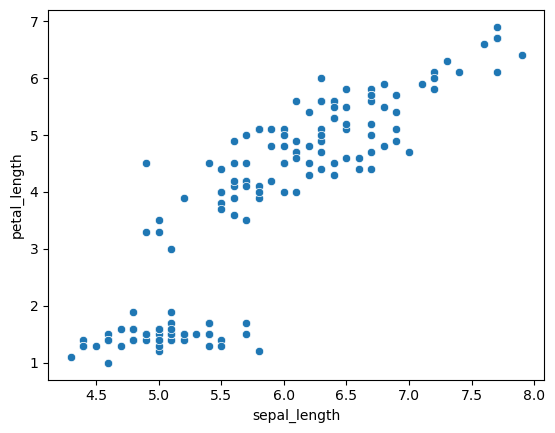

In [27]:
sns.scatterplot(x=iris.sepal_length, y=iris.petal_length)
plt.show()

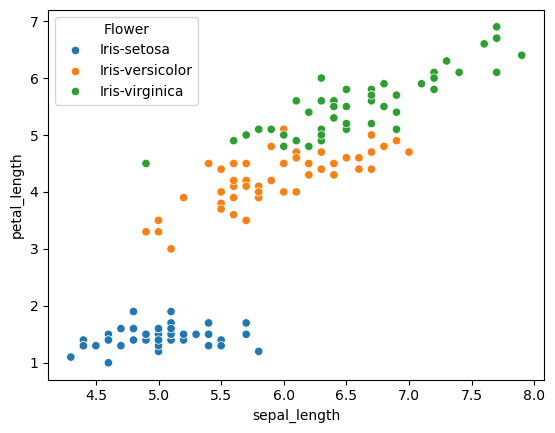

In [28]:
sns.scatterplot(x=iris.sepal_length, y=iris.petal_length, hue=iris.Flower)
plt.show()

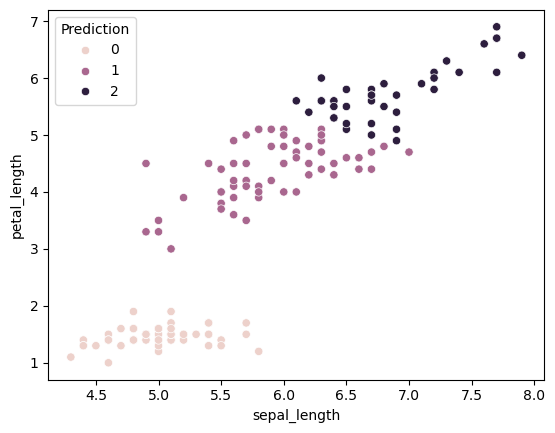

In [29]:
sns.scatterplot(x=iris.sepal_length, y=iris.petal_length, hue=iris.Prediction)
plt.show()

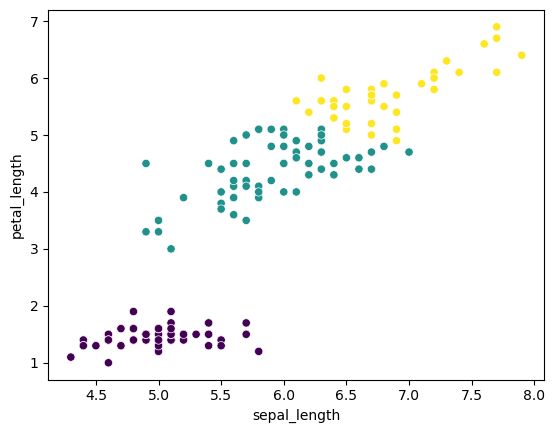

In [30]:
sns.scatterplot(x=iris.sepal_length, y=iris.petal_length, c=km_pred)
plt.show()

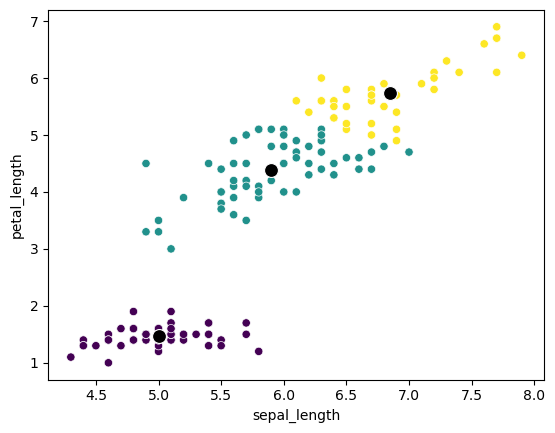

In [33]:
sns.scatterplot(x=iris.sepal_length, y=iris.petal_length, c=km_pred)
sns.scatterplot(x=centroid[::,0], y=centroid[::,2], s=100, color='k')
plt.show()
plt.show()